# Support Vector Regression (SVR)
- ##### To Predict the previous salary of a new Employee (recruit) and compare to the their expected salary
- ##### SVR is more suitable for non-linear data as it can capture complex patterns
- ##### SVR uses a non-linear kernel function to transform the data into a higher-dimensional space where it can be linearly separable
- ##### It works well when dealing with large datasets and non-linear data
- ##### SVR is sensitive to outliers and can be influenced by them
- ##### SVR is not as interpretable as other models like Linear Regression or Decision Trees
- ##### SVR is not suitable for datasets with a small number of samples
- ##### SVR can be computationally expensive for large datasets
- ##### SVR is a good choice when the dataset is large, has a non-linear relationship, and the noise is not too high
- ##### SVR is a good choice when the dataset is small, has a non-linear relationship, and the noise is high
- ##### SVR can be used for regression problems and classification problems

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme()

## Loading the dataset

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [4]:
print(X)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [5]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [6]:
# Reshape y -  # Converting y to 2D array (required for SVR)
y = y.reshape(len(y),1)
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


## Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

In [8]:
print(X)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [9]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


## Training the SVR model on the whole dataset

In [10]:
from sklearn.svm import SVR

svr_regressor = SVR(kernel = 'rbf', verbose=True) # radial basis function (rbf) kernel
svr_regressor.fit(X, y)

[LibSVM]*
optimization finished, #iter = 11
obj = -2.398637, rho = -0.011581
nSV = 5, nBSV = 2


/Users/apple/PycharmProjects/AI_ML_Robotics_Data Science_Bootcamps/tf-env/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(verbose=True)

## Predicting a new result (salary) - using the scaled values

In [11]:
# Inversing the scaling to get the original salary
sc_y.inverse_transform(svr_regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

## Visualising the SVR results

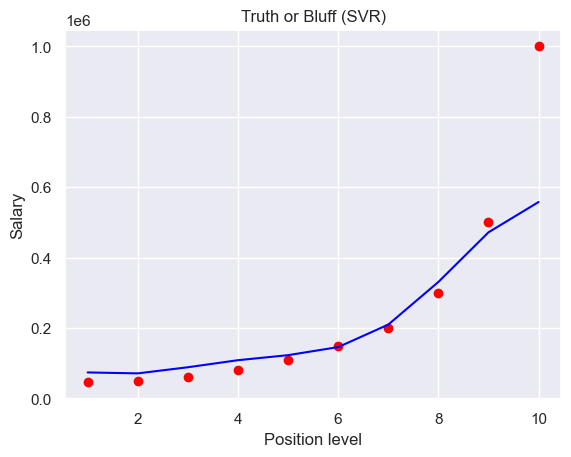

In [12]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color ='red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(svr_regressor.predict(X).reshape(-1,1)), color ='blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## Visualising the SVR results (for higher resolution and smoother curve)

/var/folders/x4/dd2xz8_d4fjbb7kzdq5sp8_40000gn/T/ipykernel_11806/4148101393.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)


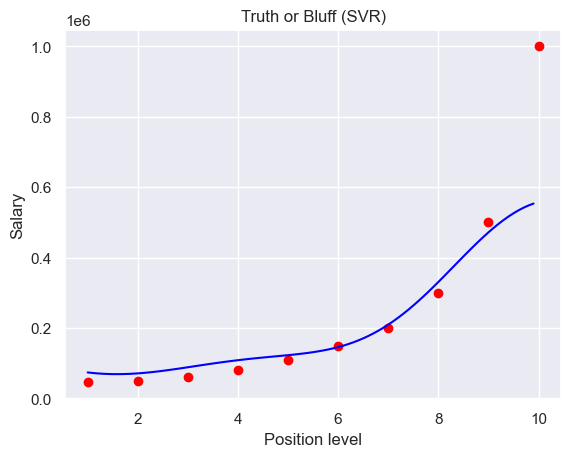

In [13]:
X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color ='red')
plt.plot(X_grid, sc_y.inverse_transform(svr_regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color ='blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()